<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
print("Downloading dataset...")
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

file_path = f"{path}/heart_disease_uci.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

df.head()

100%|██████████| 12.4k/12.4k [00:00<00:00, 22.2MB/s]

Extracting files...
Dataset Loaded Successfully
Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print("Dataset Information")
df.info()

print("\nSummary Statistics")
print(df.describe())

print("\nMissing Values")
print(df.isna().sum())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Summary Statistics
               id         age    trestbps        chol      thalch     oldpeak  \
count  9

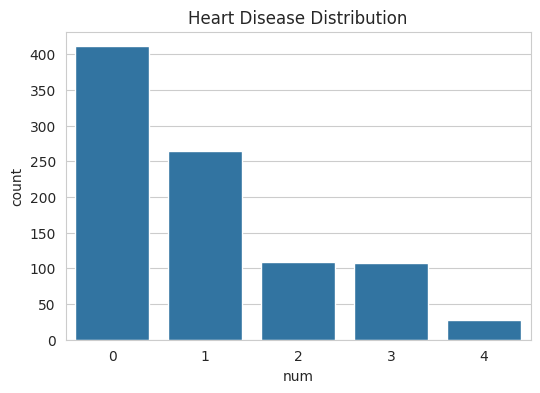

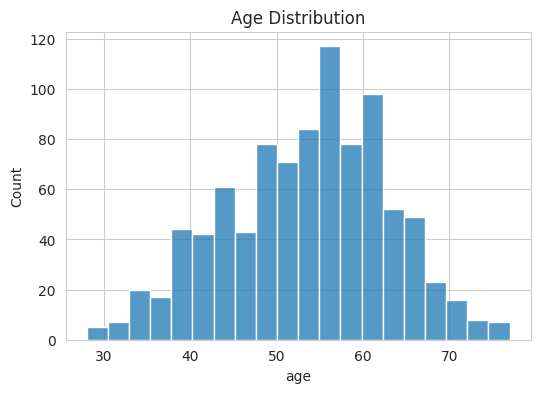

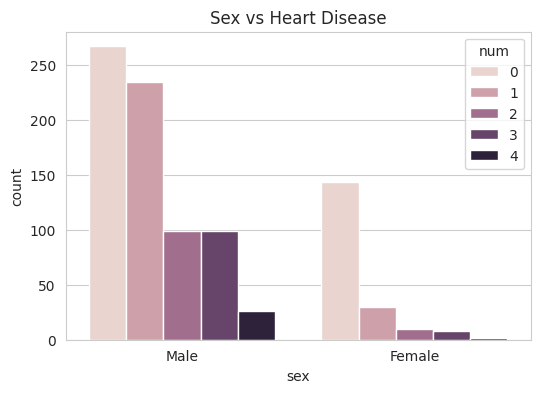

In [4]:
sns.set_style("whitegrid")

#Target Distribution

plt.figure(figsize=(6,4))
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

#Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

#Sex vs Disease

plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='num', data=df)
plt.title("Sex vs Heart Disease")
plt.show()

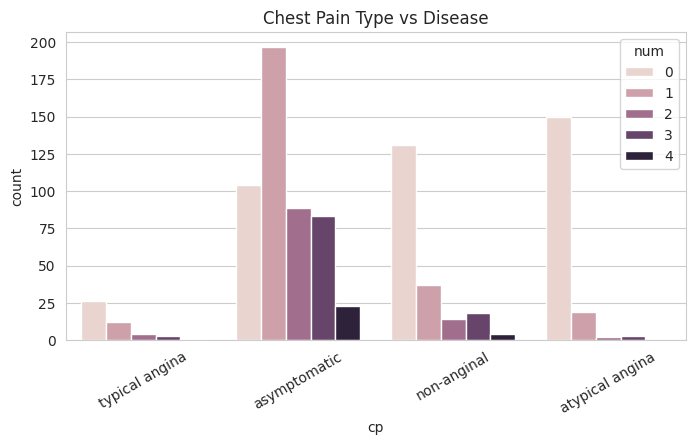

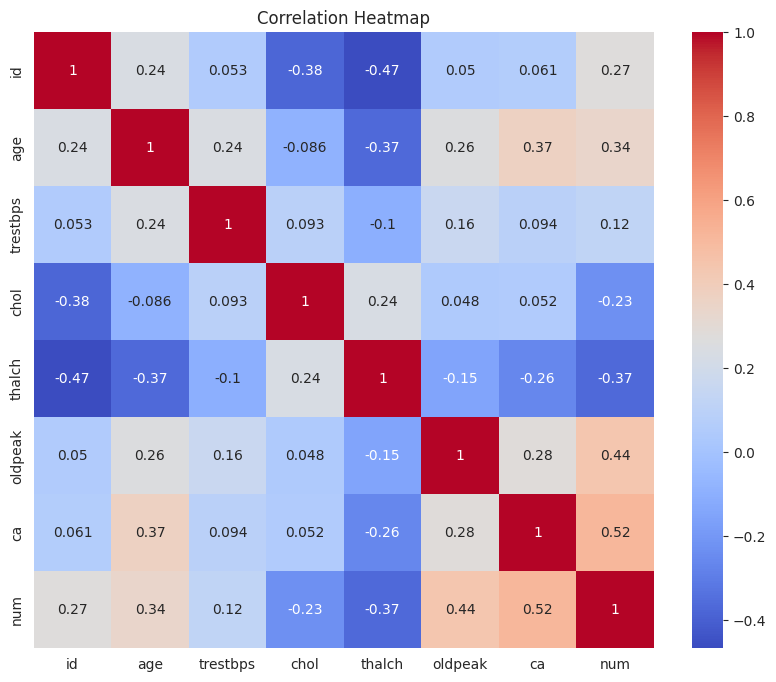

In [5]:
#Chest Pain vs Disease

plt.figure(figsize=(8,4))
sns.countplot(x='cp', hue='num', data=df)
plt.title("Chest Pain Type vs Disease")
plt.xticks(rotation=30)
plt.show()

#Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [6]:
df = df.drop(['id','dataset'], axis=1)
df['num'] = df['num'].apply(lambda x: 1 if x>0 else 0)
X = df.drop('num', axis=1)
y = df['num']

In [7]:
X = df.drop('num', axis=1)
y = df['num']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
categorical_cols = X_train.select_dtypes(include=['object','bool']).columns
numerical_cols = X_train.select_dtypes(include=['int64','float64']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: Index(['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='object')
Numerical Columns: Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca'], dtype='object')


In [10]:
num_imputer = SimpleImputer(strategy="mean")
X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])



cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

In [12]:
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown='ignore')

encoded_train = encoder.fit_transform(X_train[categorical_cols])
encoded_test = encoder.transform(X_test[categorical_cols])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(categorical_cols))
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(categorical_cols))



X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)



X_train = X_train.drop(categorical_cols, axis=1)
X_test = X_test.drop(categorical_cols, axis=1)



X_train = pd.concat([X_train, encoded_train_df], axis=1)
X_test = pd.concat([X_test, encoded_test_df], axis=1)

In [13]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [14]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)



rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [15]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nLogistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest Report")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8315217391304348
Random Forest Accuracy: 0.8478260869565217

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.83      0.78      0.81        82
           1       0.83      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184


Random Forest Report
              precision    recall  f1-score   support

           0       0.86      0.78      0.82        82
           1       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



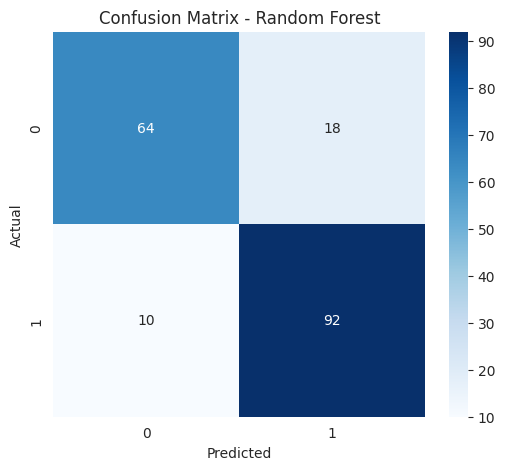

In [16]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

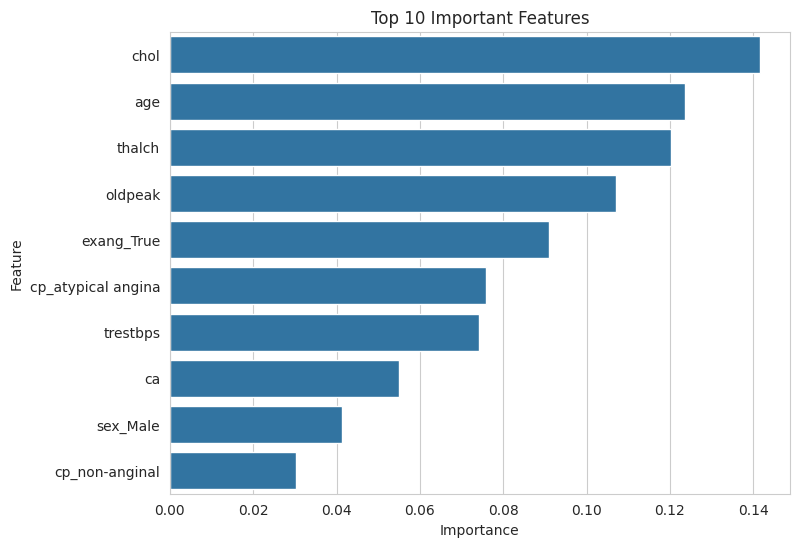

In [17]:
importances = rf_model.feature_importances_

features = X_train.columns

importance_df = pd.DataFrame({
"Feature": features,
"Importance": importances
})

importance_df = importance_df.sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)

plt.title("Top 10 Important Features")

plt.show()

In [18]:
# Loaded the UCI Heart Disease dataset

# Performed Exploratory Data Analysis (EDA)

# Cleaned the dataset and handled missing values

# Encoded categorical features using OneHotEncoder

# Scaled numerical features using StandardScaler

# Trained Logistic Regression and Random Forest models

# Evaluated models using accuracy, classification report, and confusion matrix